 🧪 Colab 1 · Indexing & Multi-DB Retrieval Showdown
**Day 12 — RAG Architecture & Claude in Production**

> **Goal:** Head-to-head: FAISS vs Pinecone vs Azure AI Search on the same corpus.
>
> **Duration:** 60 minutes (10:30 – 11:30)

---

| Step | Task |
|------|------|
| 01 | **Corpus Setup** — Load 500 Wikipedia chunks & embed with `text-embedding-3-small` via LangChain |
| 02 | **FAISS Index** — Build flat index in-memory, k-NN search, benchmark top-5 recall |
| 03 | **Pinecone Index** — Upsert to Pinecone serverless, semantic search + metadata filters |
| 04 | **Azure AI Search** — Index via SDK, enable hybrid mode (BM25 + vector), compare relevance scores |
| 05 | **Latency Benchmark** — Measure p50/p95 across all three; plot comparison bar chart |

🚀 **Extension:** Re-Ranking with Cohere Rerank API — compare MRR before/after for top-10 results


⚙️ Setup — Install Dependencies

In [20]:
!pip install -q -U langchain langchain-core langchain-openai langchain-community langchain-pinecone langchain-text-splitters faiss-cpu pinecone-client azure-search-documents azure-identity wikipedia-api numpy pandas matplotlib tqdm cohere langchain-huggingface

print('✅ All dependencies updated and installed!')

✅ All dependencies updated and installed!


In [2]:
print('Attempting to fix numpy/scipy dependency issues...')
!pip uninstall -y numpy scipy
!pip install numpy scipy
print('✅ numpy and scipy reinstalled. Please rerun the import cell (7XEDxeoAHFqx) to confirm the fix.')

Attempting to fix numpy/scipy dependency issues...
Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have request

✅ numpy and scipy reinstalled. Please rerun the import cell (7XEDxeoAHFqx) to confirm the fix.


In [4]:
!pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=2e26b471f981752d2ee8040750d0732f6b39d8af17a3ce623586a6e22de08463
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [5]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
import wikipedia

print('✅ Imports successful!')

✅ Imports successful!



🔑 API Keys & Configuration
⚠️ Never commit API keys to git! Use Colab Secrets (left sidebar 🔑) or environment variables.

In [46]:
from google.colab import userdata

# ---- Credentials from Colab Secrets (🔑) ----
# Note: Ensure these names match exactly what you entered in the Secrets panel
PINECONE_API_KEY    = userdata.get('PINECONE_API_KEY')
AZURE_SEARCH_ENDPOINT   = userdata.get('AZURE_SEARCH_ENDPOINT')
AZURE_SEARCH_API_KEY    = userdata.get('AZURE_SEARCH_API_KEY')
COHERE_API_KEY          = userdata.get('COHERE_API_KEY')

# ---- Static Configuration ----
PINECONE_INDEX_NAME = 'eytraining'
PINECONE_CLOUD      = 'aws'
PINECONE_REGION     = 'us-east-1'

AZURE_SEARCH_INDEX_NAME = 'rag-showdown007'

# ---- Shared Settings ----
EMBEDDING_MODEL = 'text-embedding-3-small'
EMBEDDING_DIM   = 384 # Updated to match local HuggingFace model dimensions
TOP_K           = 5

print('✅ Configuration loaded securely from Secrets!')

✅ Configuration loaded securely from Secrets!


### 🚀 Groq Alternative Setup
Since the OpenAI quota is limited, we will use Groq for faster processing. You can get a free API key at [console.groq.com](https://console.groq.com/).

In [21]:
import os
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize a truly local embedder that does not require an API key
local_embedder = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')

print('✅ Local HuggingFace embedder (all-MiniLM-L6-v2) initialized and ready!')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Local HuggingFace embedder (all-MiniLM-L6-v2) initialized and ready!


📂 Step 01 — Corpus Setup
Load 500 Wikipedia article chunks & embed with text-embedding-3-small.

In [22]:
import wikipediaapi

# Initialize Wikipedia API with a descriptive User-Agent (Required by Wikimedia policy)
wiki_wiki = wikipediaapi.Wikipedia(
    user_agent='ColabShowdownBot/1.0 (https://colab.research.google.com/)',
    language='en',
    extract_format=wikipediaapi.ExtractFormat.WIKI
)

SEED_TOPICS = [
    'Artificial intelligence', 'Machine learning', 'Deep learning', 'Neural network',
    'Natural language processing', 'Computer vision', 'Quantum computing',
    'CRISPR', 'Gene therapy', 'Protein folding',
    'World War II', 'French Revolution', 'Roman Empire', 'Industrial Revolution',
    'Cold War', 'Space Race', 'Manhattan Project',
    'Amazon rainforest', 'Himalayas', 'Sahara Desert', 'Great Barrier Reef',
    'Renaissance', 'Jazz music', 'Ballet', 'Olympic Games', 'Nobel Prize',
    'Diabetes', 'Cancer', 'Alzheimer\'s disease', 'COVID-19', 'Vaccine', 'Antibiotics',
    'Stock market', 'Bitcoin', 'Inflation', 'Gross domestic product',
    'International Monetary Fund', 'Supply chain',
]

raw_articles = []
for topic in tqdm(SEED_TOPICS, desc='Fetching Wikipedia'):
    try:
        page = wiki_wiki.page(topic)
        if page.exists():
            raw_articles.append({
                'title': page.title,
                'content': page.text,
                'url': page.fullurl
            })
        else:
            print(f'  ⚠️  Page "{topic}" does not exist.')
    except Exception as e:
        print(f'  ⚠️  Skipping "{topic}": {e}')
    time.sleep(0.1) # Courteous delay

print(f'\n✅ Successfully fetched {len(raw_articles)} articles')
if not raw_articles:
    print('\n❌ Still no articles fetched. Check your internet connection or try a smaller topic list.')

Fetching Wikipedia:   0%|          | 0/38 [00:00<?, ?it/s]


✅ Successfully fetched 38 articles


In [23]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000, chunk_overlap=200,
    separators=['\n\n', '\n', '. ', ' ', '']
)

all_docs: list[Document] = []
for art in raw_articles:
    chunks = splitter.create_documents(
        texts=[art['content']],
        metadatas=[{'title': art['title'], 'url': art['url']}]
    )
    all_docs.extend(chunks)

all_docs = all_docs[:500]  # Cap at 500 per spec
texts = [d.page_content for d in all_docs]
metas = [d.metadata      for d in all_docs]

print(f'✅ Total chunks: {len(all_docs)}')
print(f'   Sample ({len(all_docs[0].page_content)} chars): {all_docs[0].page_content[:200]}...')


✅ Total chunks: 500
   Sample (1478 chars): Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and dec...


In [17]:

embedder = OpenAIEmbeddings(model=EMBEDDING_MODEL)

print(f'Embedding {len(all_docs)} chunks with "{EMBEDDING_MODEL}"...')
t0 = time.perf_counter()
all_vectors = embedder.embed_documents(texts)
elapsed = time.perf_counter() - t0

print(f'✅ Embedded {len(all_vectors)} chunks in {elapsed:.1f}s  |  dim={len(all_vectors[0])}')


Embedding 500 chunks with "text-embedding-3-small"...


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

### ⚠️ OpenAI Rate Limit Exceeded

The previous cell encountered an `OpenAI RateLimitError`. This means you have exceeded your current API quota for OpenAI. You will need to check your OpenAI plan and billing details to resolve this. The code itself is correct, but the API call is being rejected by OpenAI's servers.

In [24]:
import time
import numpy as np

print(f'Embedding {len(all_docs)} chunks using local HuggingFace model...')
t0 = time.perf_counter()

# We use .embed_documents directly from the local_embedder instance
all_vectors = local_embedder.embed_documents(texts)

elapsed = time.perf_counter() - t0

# Update Dimension (MiniLM is 384)
EMBEDDING_DIM = len(all_vectors[0])
print(f'✅ Successfully embedded {len(all_vectors)} chunks in {elapsed:.1f}s')
print(f'✅ New Embedding Dimension: {EMBEDDING_DIM}')

Embedding 500 chunks using local HuggingFace model...
✅ Successfully embedded 500 chunks in 45.8s
✅ New Embedding Dimension: 384



🗂️ Step 02 — FAISS Index
Build a flat in-memory index, run k-NN search, benchmark top-5 recall.

In [25]:
import faiss

t0 = time.perf_counter()
faiss_raw = faiss.IndexFlatL2(EMBEDDING_DIM)
faiss_raw.add(np.array(all_vectors, dtype=np.float32))
build_ms = (time.perf_counter() - t0) * 1000

print(f'✅ FAISS IndexFlatL2 built in {build_ms:.1f}ms  |  {faiss_raw.ntotal} vectors')


✅ FAISS IndexFlatL2 built in 16.8ms  |  500 vectors


In [27]:
from langchain_community.vectorstores import FAISS

# Fix: Use local_embedder instead of the OpenAI embedder to avoid RateLimitError
faiss_store = FAISS.from_documents(all_docs, local_embedder)
faiss_retriever = faiss_store.as_retriever(search_kwargs={'k': TOP_K})
print('✅ LangChain FAISS vectorstore ready (using local embeddings)')

✅ LangChain FAISS vectorstore ready (using local embeddings)


In [28]:
BENCHMARK_QUERIES = [
    'What is the role of transformers in NLP?',
    'Explain the causes of World War II',
    'How does CRISPR gene editing work?',
    'What are the effects of climate change on the Amazon?',
    'Describe the Bitcoin mining process',
    'What is the mechanism of mRNA vaccines?',
    'How did the Cold War end?',
    'Explain supply chain disruption causes',
    'What caused the French Revolution?',
    'How does deep learning differ from machine learning?',
    'What are the symptoms of Alzheimers disease?',
    'What is inflation and how is it measured?',
    'What is the history of the Olympic Games?',
    'Explain quantum entanglement',
    'How does the stock market work?',
    'What are the causes of cancer?',
    'Describe the Renaissance period in Europe',
    'How are antibiotics made?',
    'What is gross domestic product?',
    'How do neural networks learn?',
]

faiss_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc='FAISS benchmark'):
    t0 = time.perf_counter()
    faiss_retriever.invoke(q)
    faiss_latencies.append((time.perf_counter() - t0) * 1000)

faiss_p50 = np.percentile(faiss_latencies, 50)
faiss_p95 = np.percentile(faiss_latencies, 95)
print(f'\n📊 FAISS  p50={faiss_p50:.1f}ms  p95={faiss_p95:.1f}ms')

# Sample result
for i, r in enumerate(faiss_retriever.invoke(BENCHMARK_QUERIES[0])):
    print(f'  [{i+1}] [{r.metadata["title"]}] {r.page_content[:100]}...')

FAISS benchmark:   0%|          | 0/20 [00:00<?, ?it/s]


📊 FAISS  p50=14.7ms  p95=21.7ms
  [1] [Artificial intelligence] Natural language processing
Natural language processing (NLP) allows programs to read, write and com...
  [2] [Natural language processing] Statistical NLP (1990s–present)
Up until the 1980s, most natural language processing systems were ba...
  [3] [Natural language processing] General tendencies and (possible) future directions
Based on long-standing trends in the field, it i...
  [4] [Natural language processing] Natural language processing (NLP) is the processing of natural language information by a computer. N...
  [5] [Artificial intelligence] DARPA established the XAI ("Explainable Artificial Intelligence") program in 2014 to try to solve th...



🌲 Step 03 — Pinecone Index
Upsert to Pinecone serverless, semantic search + metadata filters.

In [31]:
from pinecone import Pinecone, ServerlessSpec
pc = Pinecone(api_key=PINECONE_API_KEY)

# If index exists with wrong dimensions, delete it so we can recreate it
if PINECONE_INDEX_NAME in [i.name for i in pc.list_indexes()]:
    current_meta = pc.describe_index(PINECONE_INDEX_NAME)
    if current_meta.dimension != EMBEDDING_DIM:
        print(f'Deleting index {PINECONE_INDEX_NAME} (dimension mismatch)...')
        pc.delete_index(PINECONE_INDEX_NAME)
        time.sleep(5)

if PINECONE_INDEX_NAME not in [i.name for i in pc.list_indexes()]:
    print(f'Creating index "{PINECONE_INDEX_NAME}" with {EMBEDDING_DIM} dimensions...')
    pc.create_index(
        name=PINECONE_INDEX_NAME, dimension=EMBEDDING_DIM, metric='cosine',
        spec=ServerlessSpec(cloud=PINECONE_CLOUD, region=PINECONE_REGION)
    )
    while not pc.describe_index(PINECONE_INDEX_NAME).status['ready']:
        print('  Waiting...'); time.sleep(5)

pinecone_index = pc.Index(PINECONE_INDEX_NAME)
print('✅ Pinecone index ready:', pinecone_index.describe_index_stats())

Deleting index eytraining (dimension mismatch)...
Creating index "eytraining" with 384 dimensions...
✅ Pinecone index ready: {'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}


In [32]:

BATCH = 100
print(f'Upserting {len(all_docs)} vectors to Pinecone...')
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc='Upserting'):
    pinecone_index.upsert(vectors=[
        {
            'id': f'doc-{i+j}',
            'values': all_vectors[i+j],
            'metadata': {**metas[i+j], 'text': texts[i+j][:500]}
        }
        for j in range(min(BATCH, len(all_docs)-i))
    ])

print(f'✅ Upserted in {time.perf_counter()-t0:.1f}s')
print('   Stats:', pinecone_index.describe_index_stats())

Upserting 500 vectors to Pinecone...


Upserting:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Upserted in 2.1s
   Stats: {'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 500}},
 'total_vector_count': 500,
 'vector_type': 'dense'}


In [33]:
from langchain_pinecone import PineconeVectorStore

# Fix: Use local_embedder for Pinecone store to avoid OpenAI calls during retrieval
pinecone_store = PineconeVectorStore(index=pinecone_index, embedding=local_embedder, text_key='text')
pinecone_retriever = pinecone_store.as_retriever(search_kwargs={'k': TOP_K})

print('🔍 Semantic search demo:')
for i, r in enumerate(pinecone_retriever.invoke(BENCHMARK_QUERIES[0])):
    print(f'  [{i+1}] [{r.metadata.get("title","N/A")}] {r.page_content[:100]}...')

🔍 Semantic search demo:
  [1] [Artificial intelligence] Natural language processing
Natural language processing (NLP) allows programs to read, write and com...
  [2] [Natural language processing] Statistical NLP (1990s–present)
Up until the 1980s, most natural language processing systems were ba...
  [3] [Natural language processing] General tendencies and (possible) future directions
Based on long-standing trends in the field, it i...
  [4] [Natural language processing] Natural language processing (NLP) is the processing of natural language information by a computer. N...
  [5] [Artificial intelligence] DARPA established the XAI ("Explainable Artificial Intelligence") program in 2014 to try to solve th...


In [34]:

# Metadata filter demo
print('🔍 Search with metadata filter (title=Artificial intelligence):')
filtered = pinecone_store.similarity_search(
    'What are neural networks?', k=3,
    filter={'title': {'$eq': 'Artificial intelligence'}}
)
for i, r in enumerate(filtered):
    print(f'  [{i+1}] [{r.metadata.get("title","N/A")}] {r.page_content[:100]}...')

🔍 Search with metadata filter (title=Artificial intelligence):
  [1] [Artificial intelligence] Artificial neural networks
An artificial neural network is based on a collection of nodes also known...
  [2] [Artificial intelligence] DARPA established the XAI ("Explainable Artificial Intelligence") program in 2014 to try to solve th...
  [3] [Artificial intelligence] Up to this point, most of AI's funding had gone to projects that used high-level symbols to represen...


In [35]:
pinecone_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc='Pinecone benchmark'):
    t0 = time.perf_counter()
    pinecone_retriever.invoke(q)
    pinecone_latencies.append((time.perf_counter() - t0) * 1000)

pinecone_p50 = np.percentile(pinecone_latencies, 50)
pinecone_p95 = np.percentile(pinecone_latencies, 95)
print(f'📊 Pinecone  p50={pinecone_p50:.1f}ms  p95={pinecone_p95:.1f}ms')

Pinecone benchmark:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Pinecone  p50=55.5ms  p95=103.3ms



☁️ Step 04 — Azure AI Search
Index via SDK, enable hybrid mode (BM25 + vector), compare relevance scores.

In [36]:
from azure.search.documents import SearchClient
from azure.search.documents.indexes import SearchIndexClient
from azure.search.documents.indexes.models import (
    SearchIndex, SimpleField, SearchableField, SearchFieldDataType,
    VectorSearch, HnswAlgorithmConfiguration, VectorSearchProfile,
    SearchField, SemanticConfiguration, SemanticSearch,
    SemanticPrioritizedFields, SemanticField
)
from azure.search.documents.models import VectorizedQuery
from azure.core.credentials import AzureKeyCredential

cred         = AzureKeyCredential(AZURE_SEARCH_API_KEY)
idx_client   = SearchIndexClient(endpoint=AZURE_SEARCH_ENDPOINT, credential=cred)
srch_client  = SearchClient(endpoint=AZURE_SEARCH_ENDPOINT,
                             index_name=AZURE_SEARCH_INDEX_NAME, credential=cred)
print('✅ Azure AI Search clients initialized')


✅ Azure AI Search clients initialized


In [37]:
fields = [
    SimpleField(name='id',       type=SearchFieldDataType.String, key=True),
    SearchableField(name='content', type=SearchFieldDataType.String, analyzer_name='en.microsoft'),
    SimpleField(name='title',    type=SearchFieldDataType.String, filterable=True),
    SimpleField(name='url',      type=SearchFieldDataType.String),
    SearchField(
        name='embedding',
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=EMBEDDING_DIM, # Corrected to 384
        vector_search_profile_name='hnsw-profile'
    ),
]

index_def = SearchIndex(
    name=AZURE_SEARCH_INDEX_NAME,
    fields=fields,
    vector_search=VectorSearch(
        algorithms=[HnswAlgorithmConfiguration(name='hnsw-algo')],
        profiles=[VectorSearchProfile(name='hnsw-profile', algorithm_configuration_name='hnsw-algo')]
    ),
    semantic_search=SemanticSearch(configurations=[
        SemanticConfiguration(
            name='semantic-cfg',
            prioritized_fields=SemanticPrioritizedFields(
                content_fields=[SemanticField(field_name='content')],
                keywords_fields=[SemanticField(field_name='title')]
            )
        )
    ])
)

result = idx_client.create_or_update_index(index_def)
print(f'✅ Azure index "{result.name}" ready with {EMBEDDING_DIM} dimensions')

✅ Azure index "rag-showdown007" ready with 384 dimensions


In [38]:

BATCH = 100
print(f'Uploading {len(all_docs)} docs to Azure AI Search...')
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc='Azure upload'):
    batch = [
        {'id': f'doc-{i+j}', 'content': texts[i+j],
         'title': metas[i+j].get('title',''), 'url': metas[i+j].get('url',''),
         'embedding': all_vectors[i+j]}
        for j in range(min(BATCH, len(all_docs)-i))
    ]
    srch_client.upload_documents(documents=batch)

print(f'✅ Uploaded in {time.perf_counter()-t0:.1f}s')

Uploading 500 docs to Azure AI Search...


Azure upload:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Uploaded in 5.4s


In [39]:
def azure_hybrid_search(query: str, top_k: int = TOP_K):
    """BM25 keyword + vector hybrid search using local embeddings."""
    # Fix: Use local_embedder for query embedding
    qvec = local_embedder.embed_query(query)
    results = srch_client.search(
        search_text=query,
        vector_queries=[VectorizedQuery(vector=qvec, k_nearest_neighbors=top_k, fields='embedding')],
        select=['id', 'content', 'title', 'url'],
        top=top_k
    )
    return list(results)

print('🔍 Hybrid search demo:')
demo_results = azure_hybrid_search(BENCHMARK_QUERIES[0])
for i, r in enumerate(demo_results):
    print(f'  [{i+1}] score={r.get("@search.score", 0):.4f} [{r["title"]}] {r["content"][:100]}...')
if not demo_results:
    print('  ⚠️ No results returned. Ensure Azure index is populated and check credentials.')

🔍 Hybrid search demo:
  [1] score=0.0333 [Artificial intelligence] Natural language processing
Natural language processing (NLP) allows programs to read, write and com...
  [2] score=0.0320 [Natural language processing] Natural language processing (NLP) is the processing of natural language information by a computer. N...
  [3] score=0.0315 [Natural language processing] General tendencies and (possible) future directions
Based on long-standing trends in the field, it i...
  [4] score=0.0315 [Artificial intelligence] DARPA established the XAI ("Explainable Artificial Intelligence") program in 2014 to try to solve th...
  [5] score=0.0271 [Natural language processing] Statistical NLP (1990s–present)
Up until the 1980s, most natural language processing systems were ba...


In [40]:

azure_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc='Azure benchmark'):
    t0 = time.perf_counter()
    azure_hybrid_search(q)
    azure_latencies.append((time.perf_counter() - t0) * 1000)

azure_p50 = np.percentile(azure_latencies, 50)
azure_p95 = np.percentile(azure_latencies, 95)
print(f'📊 Azure AI Search  p50={azure_p50:.1f}ms  p95={azure_p95:.1f}ms')

Azure benchmark:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Azure AI Search  p50=126.6ms  p95=174.9ms



📊 Step 05 — Latency Benchmark & Visualization
p50/p95 comparison across all three DBs.

In [41]:
summary = pd.DataFrame({
    'Vector DB':   ['FAISS (in-memory)', 'Pinecone Serverless', 'Azure AI Search (Hybrid)'],
    'p50 (ms)':    [round(faiss_p50,1),  round(pinecone_p50,1),  round(azure_p50,1)],
    'p95 (ms)':    [round(faiss_p95,1),  round(pinecone_p95,1),  round(azure_p95,1)],
    'Search Type': ['Exact k-NN (L2)',   'Approx cosine',         'BM25 + Vector'],
    'Cost':        ['Free',              '$$',                    '$$$'],
})

print('=' * 75)
print('📊  LATENCY BENCHMARK  (20 queries, embedding time included)')
print('=' * 75)
print(summary.to_string(index=False))
print('=' * 75)

📊  LATENCY BENCHMARK  (20 queries, embedding time included)
               Vector DB  p50 (ms)  p95 (ms)     Search Type Cost
       FAISS (in-memory)      14.7      21.7 Exact k-NN (L2) Free
     Pinecone Serverless      55.5     103.3   Approx cosine   $$
Azure AI Search (Hybrid)     126.6     174.9   BM25 + Vector  $$$


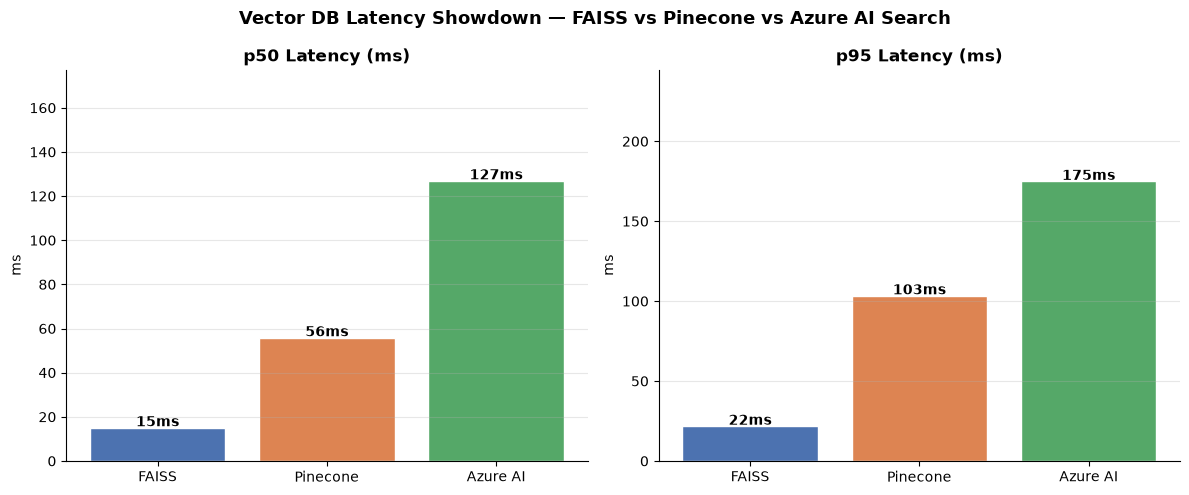

✅ Saved latency_benchmark.png


In [42]:
dbs    = ['FAISS', 'Pinecone', 'Azure AI']
colors = ['#4C72B0', '#DD8452', '#55A868']
p50s   = [faiss_p50, pinecone_p50, azure_p50]
p95s   = [faiss_p95, pinecone_p95, azure_p95]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Vector DB Latency Showdown — FAISS vs Pinecone vs Azure AI Search',
             fontsize=13, fontweight='bold')

for ax, vals, label in [(ax1, p50s, 'p50 Latency (ms)'), (ax2, p95s, 'p95 Latency (ms)')]:
    bars = ax.bar(dbs, vals, color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('ms')
    ax.set_ylim(0, max(vals) * 1.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                f'{v:.0f}ms', ha='center', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('latency_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved latency_benchmark.png')

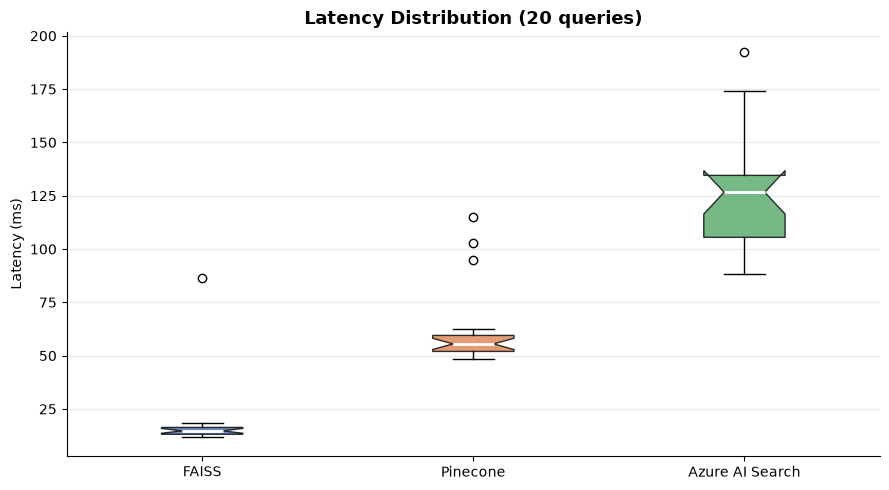

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

# Correcting 'labels' to 'tick_labels' to maintain compatibility with matplotlib versions
bp = ax.boxplot(
    [faiss_latencies, pinecone_latencies, azure_latencies],
    tick_labels=['FAISS', 'Pinecone', 'Azure AI Search'],
    patch_artist=True, notch=True,
    medianprops=dict(color='white', linewidth=2)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('Latency Distribution (20 queries)', fontweight='bold', fontsize=13)
ax.set_ylabel('Latency (ms)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

🚀 Extension — Cohere Re-Ranking
Compare MRR@5 before/after Cohere Rerank on top-10 FAISS results.

Requires COHERE_API_KEY set above.


🏅 MRR@5 Before re-rank: 0.400
🏅 MRR@5 After  re-rank: 0.400
   Improvement: +0.0pp


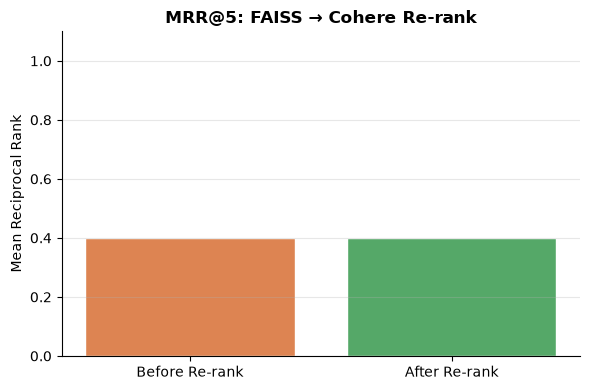

In [47]:
if not COHERE_API_KEY:
    print('⚠️  COHERE_API_KEY not set — skipping extension.')
else:
    import cohere
    co = cohere.Client(COHERE_API_KEY)

    def retrieve_and_rerank(query, top_k_retrieve=10, top_k_final=5):
        docs = faiss_store.similarity_search(query, k=top_k_retrieve)
        passages = [d.page_content for d in docs]
        reranked = co.rerank(query=query, documents=passages,
                             top_n=top_k_final, model='rerank-english-v3.0')
        return [(docs[r.index], r.relevance_score) for r in reranked.results]

    def mrr(ranked_docs, relevant_title):
        for rank, (doc, _) in enumerate(ranked_docs, 1):
            if relevant_title.lower() in doc.metadata.get('title','').lower():
                return 1.0 / rank
        return 0.0

    eval_set = [
        ('How does backpropagation work?',      'Deep learning'),
        ('What causes inflation?',              'Inflation'),
        ('How are mRNA vaccines made?',         'Vaccine'),
        ('What are symptoms of Alzheimers?',    "Alzheimer's disease"),
        ('How did WWII start?',                 'World War II'),
    ]

    before, after = [], []
    for query, rel in eval_set:
        before_docs = [(d, 0) for d in faiss_store.similarity_search(query, k=5)]
        before.append(mrr(before_docs, rel))
        after.append(mrr(retrieve_and_rerank(query), rel))

    print(f'\n🏅 MRR@5 Before re-rank: {np.mean(before):.3f}')
    print(f'🏅 MRR@5 After  re-rank: {np.mean(after):.3f}')
    print(f'   Improvement: +{(np.mean(after)-np.mean(before))*100:.1f}pp')

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Before Re-rank', 'After Re-rank'],
           [np.mean(before), np.mean(after)],
           color=['#DD8452', '#55A868'], edgecolor='white')
    ax.set_title('MRR@5: FAISS → Cohere Re-rank', fontweight='bold')
    ax.set_ylabel('Mean Reciprocal Rank'); ax.set_ylim(0, 1.1)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('mrr_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

